<a href="https://colab.research.google.com/github/santiaagoe/Machine-Learning/blob/main/01-segmentacion-clientes-marketing/segmentacion_clientes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Proyecto de Análisis de Mercado con Machine Learning y Marketing**

### **Universidad de Chile**
**Autor:** Santiago Espinoza
**Fecha:** Diciembre 2024  


##**Estructura del Notebook**

1. **Introducción y objetivos del estudio**  
2. **Carga y descripción del conjunto de datos**  
3. **Análisis exploratorio de datos (EDA)**  
4. **Preprocesamiento y limpieza de datos**  
5. **Modelado con algoritmos de machine learning**  
6. **Evaluación y visualización de resultados**  
7. **Conclusiones y recomendaciones finales**

## **Resumen del Proyecto**

El presente proyecto tiene como objetivo aplicar técnicas de análisis de datos y machine learning para comprender patrones de comportamiento en el mercado y apoyar la toma de decisiones estratégicas de marketing.  

A partir de un conjunto de datos real o simulado, se realizó una exploración completa de las variables más relevantes, identificando tendencias de consumo, segmentando clientes y evaluando posibles oportunidades comerciales.  

El proyecto combina el enfoque analítico del **data science** con la visión estratégica del **marketing moderno**, demostrando cómo el uso adecuado de herramientas de machine learning puede optimizar estrategias empresariales y mejorar la comprensión del entorno competitivo.

##**Objetivos**

**Objetivo general:**
- Analizar datos de mercado mediante herramientas estadísticas y de aprendizaje automático para obtener conclusiones que respalden la toma de decisiones estratégicas en marketing.

**Objetivos específicos:**
1. Realizar un análisis exploratorio de datos (EDA) para comprender la estructura, relaciones y calidad de la información.
2. Aplicar algoritmos de machine learning (supervisados y/o no supervisados) para identificar patrones y segmentaciones de clientes.
3. Evaluar métricas de desempeño de los modelos y seleccionar el enfoque más adecuado para el caso de estudio.
4. Visualizar resultados clave mediante gráficos y dashboards interpretables.
5. Extraer conclusiones aplicables al ámbito del marketing y proponer recomendaciones basadas en los hallazgos obtenidos.


##**Herramientas Utilizadas**

- **Lenguaje de programación:** Python  
- **Entorno de trabajo:** Jupyter Notebook  
- **Bibliotecas de análisis y modelado:**
  - `pandas`, `numpy` — manejo y análisis de datos
  - `matplotlib`, `seaborn` — visualización exploratoria
  - `scikit-learn` — modelado predictivo y clustering
  - `statsmodels` — análisis estadístico
- **Técnicas de Machine Learning:**
  - Clasificación y regresión supervisada
  - Segmentación de clientes mediante clustering (K-Means, PCA, etc.)
- **Aplicaciones de Marketing:**
  - Análisis de segmentación de mercado
  - Predicción de comportamiento de clientes
  - Estrategias basadas en datos (data-driven marketing)

#**Análisis de datos**

Comenzamos importando los módulos necesarios para el análisis de datos

In [1]:
%pip install seaborn

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (classification_report, confusion_matrix, silhouette_score,
                             roc_auc_score, roc_curve, average_precision_score)

##**Creación e implementación del dataset**

Se comienza extrayendo los datos crudos del dataset de marketing campaing, el cual contiene:
1. **Datos demográficos y personales**
ID: Identificador único del cliente.

Year_Birth: Año de nacimiento.

Education: Nivel educativo (ej: Graduation, PhD, Master, 2n Cycle, Basic).

Marital_Status: Estado civil (Single, Married, Together, Divorced, Widow, Alone).

Income: Ingresos anuales (algunos vacíos).

Kidhome: Número de niños en el hogar.

Teenhome: Número de adolescentes en el hogar.

2.** Datos de compra y gasto**
Dt_Customer: Fecha de inscripción como cliente.

Recency: Días desde la última compra.

MntWines: Gasto en vinos en los últimos 2 años.

MntFruits: Gasto en frutas.

MntMeatProducts: Gasto en productos cárnicos.

MntFishProducts: Gasto en productos pesqueros.

MntSweetProducts: Gasto en productos dulces.

MntGoldProds: Gasto en productos de oro.

3. **Comportamiento de compra y canales**
NumDealsPurchases: Número de compras con descuentos.

NumWebPurchases: Compras realizadas a través del sitio web.

NumCatalogPurchases: Compras realizadas mediante catálogo.

NumStorePurchases: Compras realizadas en tienda física.

NumWebVisitsMonth: Número de visitas al sitio web en el último mes.

4. **Respuesta a campañas de marketing**
AcceptedCmp1–5: Si el cliente aceptó la campaña 1, 2, 3, 4 o 5 (1 = sí, 0 = no).

Response: Si el cliente respondió a la última campaña (1 = sí, 0 = no).

5. **Otros datos**
Complain: Si el cliente presentó una queja en los últimos 2 años (1 = sí, 0 = no).

Z_CostContact y Z_Revenue: Posiblemente costos e ingresos estandarizados (valores constantes en este dataset).


*Se observan las primeras filas del dataset para tener una idea del contexto del mismo*



In [3]:
url = 'https://raw.githubusercontent.com/santiaagoe/Machine-Learning/main/01-segmentacion-clientes-marketing/data/marketing_campaign.csv'
dataset = pd.read_csv(url, sep='\t')
dataset

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


Analizamos sus columnas

In [4]:
dataset.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

##**Investigación de campo y variables**

Crearemos un grafico que contega los datos de cantidad de vino comprado en funcion de los ingresos

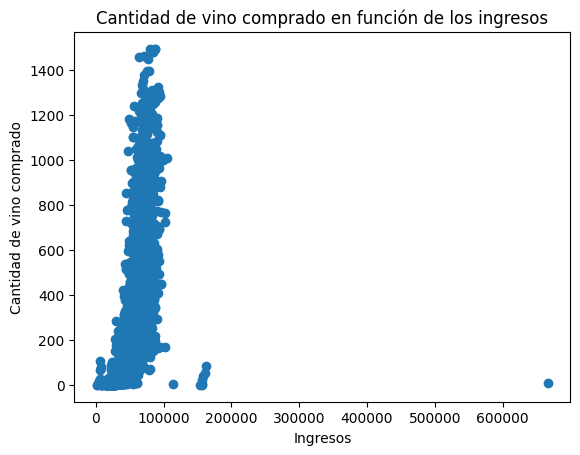

In [5]:
plt.scatter(dataset['Income'], dataset['MntWines'])
plt.xlabel("Ingresos")
plt.ylabel("Cantidad de vino comprado")
plt.title("Cantidad de vino comprado en función de los ingresos")
plt.show()



Como se puede observar, hay pocos datos que se alejan extremadamente del conjunto principal de datos, lo que perjudica el análisis de éstos

Crearemos un gráfico de catnidad de vino comprado en función de los años de nacimiento

Text(0.5, 1.0, 'Cantidad de vino comprado en función de los años de nacimiento')

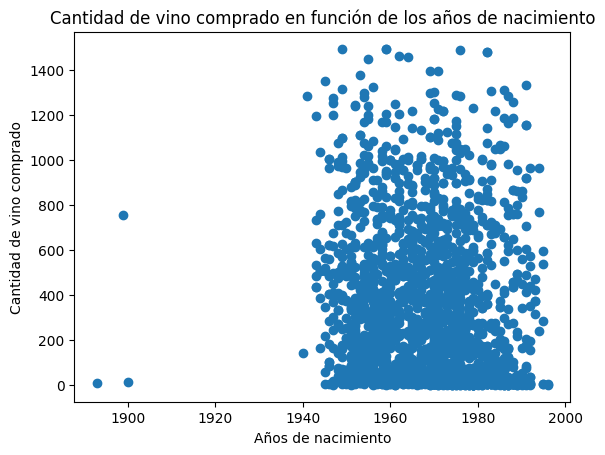

In [6]:
plt.scatter(dataset['Year_Birth'], dataset['MntWines'])
plt.xlabel("Años de nacimiento")
plt.ylabel("Cantidad de vino comprado")
plt.title("Cantidad de vino comprado en función de los años de nacimiento")

Del mismo modo que el caso anterior, hay 3 datos que se alejan del connjunto medio

Crearemos un gráfico de la cantidad de vino comprada en funcion de la carne comprada

Text(0.5, 1.0, 'Cantidad de carne comprada en función del vino comprado')

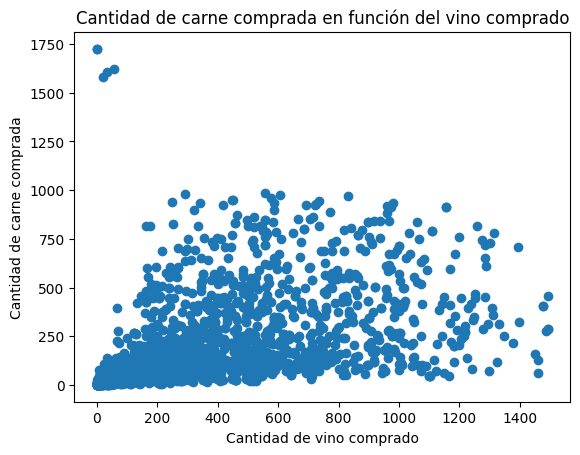

In [7]:
plt.scatter(dataset['MntWines'], dataset['MntMeatProducts'])
plt.xlabel("Cantidad de vino comprado")
plt.ylabel("Cantidad de carne comprada")
plt.title("Cantidad de carne comprada en función del vino comprado")

#**Limpieza y modificación de datos**

##**Eliminación de datos nulos**

**Modificamos elementos del dataset**

Comenzaremos borrando columnas innecesarias para el análisis

In [8]:
#Eliminamos las columnas 'ID' y 'Dt_Customer'
dataset.drop(columns=['ID','Dt_Customer'],inplace=True)

Creamos un mapa para ver los datos nulos en el dataset

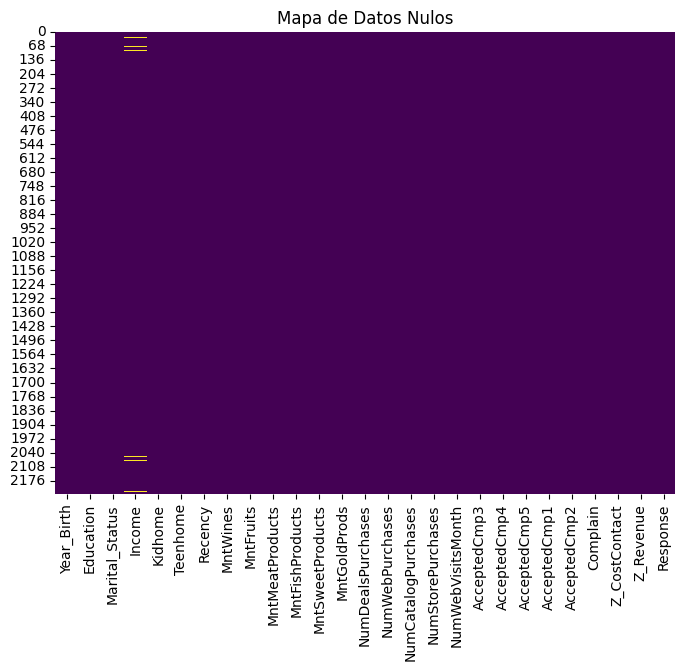

In [9]:
null_map = dataset.isnull()

# Crear un mapa de calor con seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(null_map, cbar=False, cmap='viridis', cbar_kws={'label': 'Nulos'})
plt.title('Mapa de Datos Nulos')
plt.show()

Observamos que en la columna 'Income' hay un par de datos nulos, por lo que procederemos a eliminarlos

In [10]:
#Eliminanmos los valores nulos de income con dropna
dataset.dropna(subset=['Income'], inplace=True)

Ahora observamos nuestro nuevo mapa de datos nulos


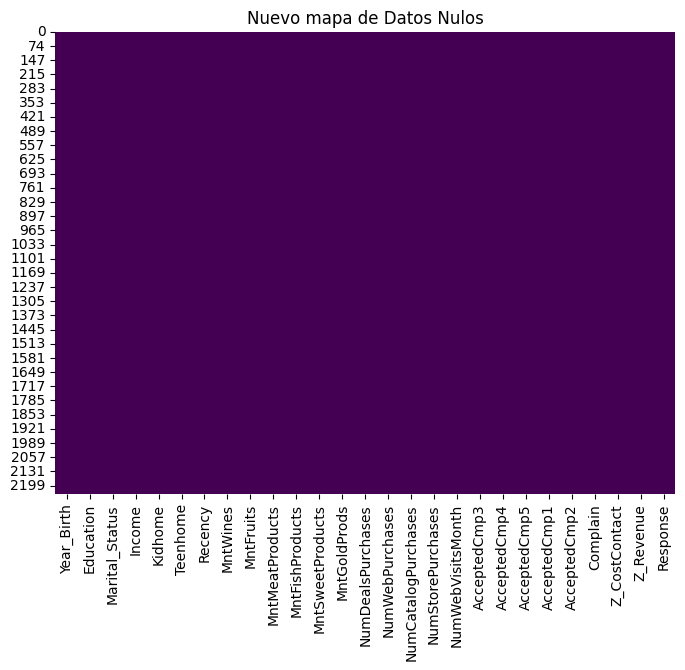

In [11]:
null_map = dataset.isnull()

# Crear un mapa de calor con seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(null_map, cbar=False, cmap='viridis', cbar_kws={'label': 'Nulos'})
plt.title('Nuevo mapa de Datos Nulos')
plt.show()

##**Modificación de variables numéricas**

Filtramos los ingresos que sean sólo menores a 100000

In [42]:
filtro_ingresos = dataset['Income'] < 100000
dataset = dataset[filtro_ingresos]

Fitramos las fechas de nacimiento sólo a mayores de 1940

In [13]:
filtro_edades = dataset['Year_Birth'] > 1940
dataset = dataset[filtro_edades]

Cambiamos fechas de naciminento por edades y borramos la columna 'Year_Birth' cambiándola por 'Edades'

In [14]:
def Edades(dataset):
  Año = dataset['Year_Birth']
  return 2024 - Año

dataset['Edades'] = Edades(dataset)

dataset.drop(columns=['Year_Birth'], inplace=True)

Unimos las columnas de Kidhome y Teenhome como la suma de ambos en 'N_hijos'

In [15]:
def Hijostotal(dataset):
  Ninos = dataset['Kidhome']
  Jovenes = dataset['Teenhome']
  return Ninos + Jovenes

dataset['N_hijos'] = Hijostotal(dataset)
#Borramos las columnas 'Kidhome' y 'Teenhome'
dataset.drop(columns=['Kidhome', 'Teenhome'], inplace=True)

##**Modificación de columnas de strings a valores numéricos**

Modificamos la columna 'Education'

In [16]:
dataset['Educacion'] = pd.Categorical(dataset['Education']).codes
#En Educacion, los valores quedan como
# 0 -> 2n Cycle
# 1 -> Basic
# 2 -> Graduation
# 3 -> Master
# 4 -> PhD

Modificamos la columna 'Marital_Status'

In [17]:
#Primero eliminamos las filas que tengan como estado civil 'Alone', 'Absurd' y 'YOLO'
dataset = dataset[~dataset['Marital_Status'].isin(['Alone', 'Absurd', 'YOLO'])]

dataset['Estado_Civil'] = pd.Categorical(dataset['Marital_Status']).codes
#En Estado_Civil, los valores quedan como
# 0 -> Divorced
# 1 -> Married
# 2 -> Single
# 3 -> Together
# 4 -> Widow

#**Nuevo análisis de datos (*post modificación*)**

##**Relación con edades**

Análisis de edades con histogramas para análisis de frecuencias de clientes

Text(0.5, 1.0, 'Histograma de Edades')

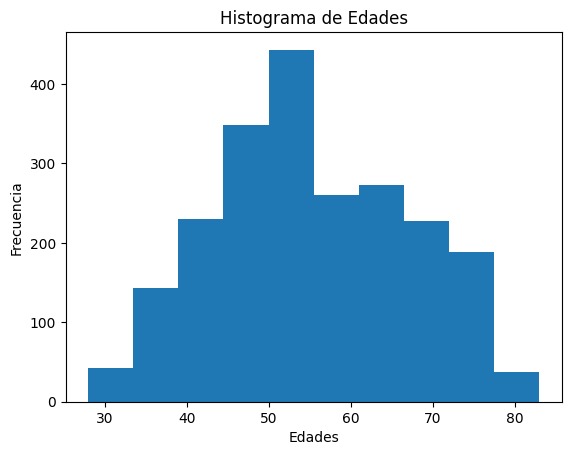

In [18]:
plt.hist(dataset['Edades'])
plt.xlabel("Edades")
plt.ylabel("Frecuencia")
plt.title("Histograma de Edades")

Análisis de cantidad de vino comprado en función de las edades

Text(0, 0.5, 'Vino comprado')

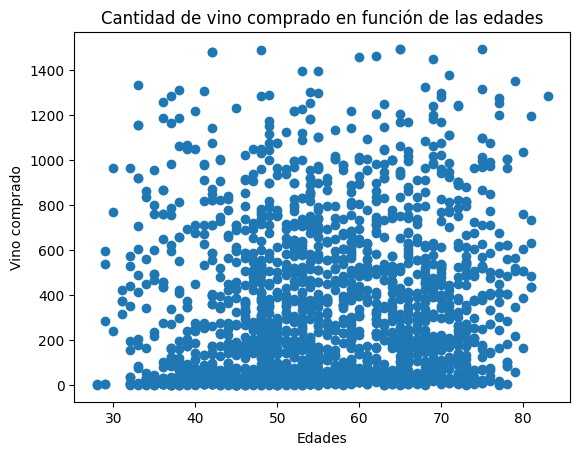

In [19]:
plt.scatter(dataset['Edades'], dataset['MntWines'])
plt.title("Cantidad de vino comprado en función de las edades")
plt.xlabel('Edades')
plt.ylabel('Vino comprado')

##**Relación con datos cualitativos**

Ahora analizamos datos con dominios discretos y cualitativos

---



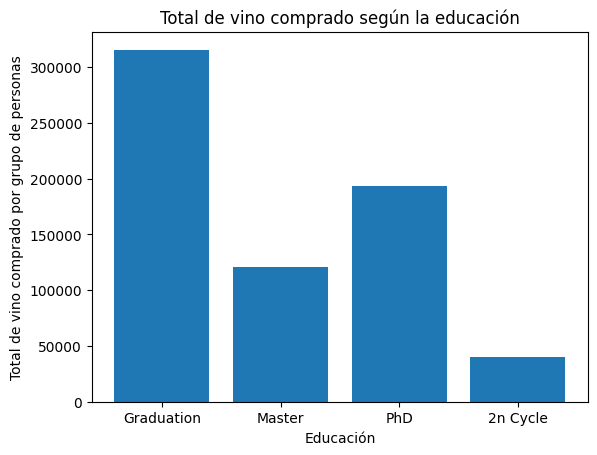

In [20]:
Datos = np.transpose(np.array([dataset['Education'],dataset['MntWines']]))
Educaciones = np.array([['Graduation',0],['Master',0],['PhD',0],['2n Cycle',0]])
def EducacionXIngreso(Datos):
  a = 0
  for i in Educaciones:
    b = 0
    for j in Datos:
      if Datos[b][0] == Educaciones[a][0]:
        Educaciones[a][1] = int(Educaciones[a][1]) + int(Datos[b][1])
        Educaciones[a][1] = int(Educaciones[a][1])
        b = b +1
      else:
        b = b+1
    a = a+1

EducacionXIngreso(Datos)

Valores = list(Educaciones[ : , 1])
for i in range(len(Valores)):
  Valores[i] = int(Valores[i])
plt.bar(list(Educaciones[ : , 0]),Valores)
plt.title('Total de vino comprado según la educación')
plt.xlabel('Educación')
plt.ylabel('Total de vino comprado por grupo de personas')
plt.show()

Analizamos el estado civil de los individuos con la cantidad de vino que compran en total

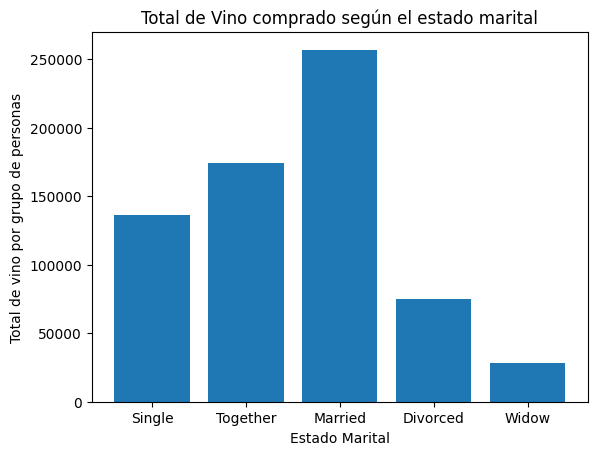

In [21]:

Datos = np.transpose(np.array([dataset['Marital_Status'],dataset['MntWines']]))
Estados = np.array([['Single',0],['Together',0],['Married',0],['Divorced',0],['Widow',0]])
def EstadoXIngreso(Datos):
  a = 0
  for i in Estados:
    b = 0
    for j in Datos:
      if Datos[b][0] == Estados[a][0]:
        Estados[a][1] = int(Estados[a][1]) + int(Datos[b][1])
        b = b +1
      else:
        b = b+1
    a = a+1

EstadoXIngreso(Datos)
Valores = list(Estados[ : , 1])
for i in range(len(Valores)):
  Valores[i] = int(Valores[i])

plt.bar(Estados[ : , 0],Valores)
plt.title('Total de Vino comprado según el estado marital')
plt.xlabel('Estado Marital')
plt.ylabel('Total de vino por grupo de personas')
plt.show()

##**Relación con compra de otros productos**

Relación entre compra de vino y compra de carne

Text(0, 0.5, 'Carne comprada')

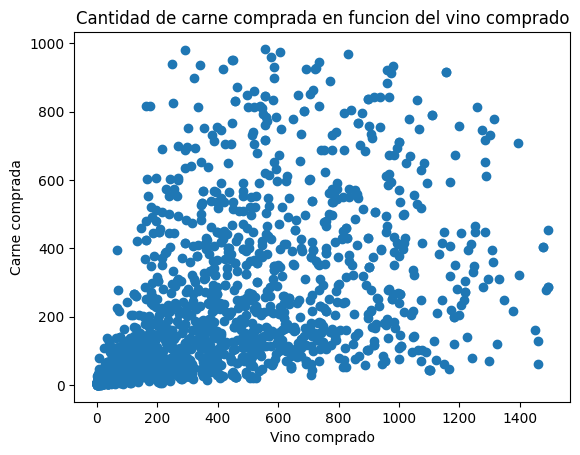

In [22]:
#Eliminamos el valor de carne sobre 1500
dataset.drop(dataset[dataset['MntMeatProducts'] > 1500].index, inplace=True)

plt.scatter(dataset['MntWines'], dataset['MntMeatProducts'])
plt.title("Cantidad de carne comprada en funcion del vino comprado")
plt.xlabel('Vino comprado')
plt.ylabel('Carne comprada')

Relación entre compra de vino y compra de frutas

Text(0, 0.5, 'Frutas')

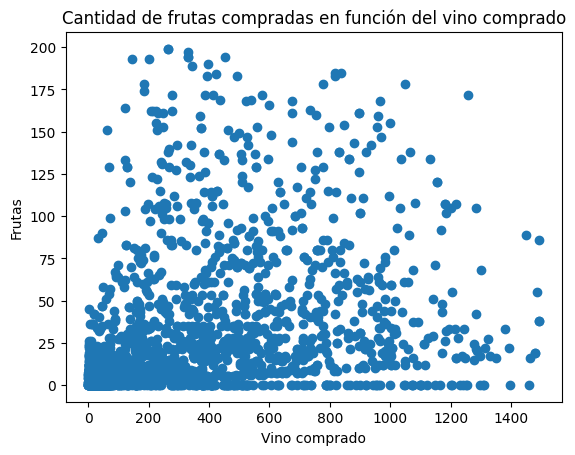

In [23]:
plt.scatter(dataset['MntWines'], dataset['MntFruits'])
plt.title("Cantidad de frutas compradas en función del vino comprado")
plt.xlabel('Vino comprado')
plt.ylabel('Frutas')

Relación entre compra de vino y compra de pescado

Text(0, 0.5, 'Pescado comprado')

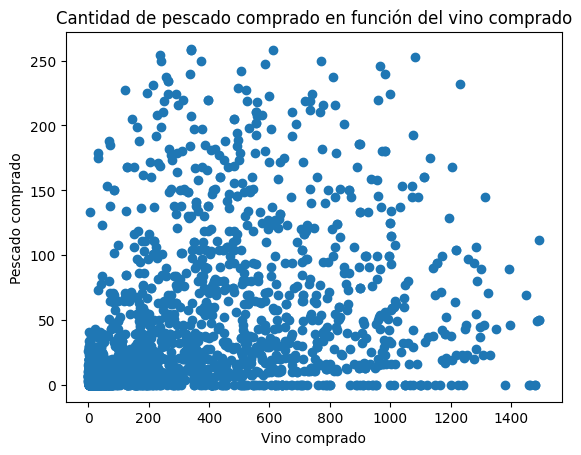

In [24]:
plt.scatter(dataset['MntWines'], dataset['MntFishProducts'])
plt.title("Cantidad de pescado comprado en función del vino comprado")
plt.xlabel('Vino comprado')
plt.ylabel('Pescado comprado')

Relación entre compra de vino y compra de dulces

Text(0, 0.5, 'Dulces comprados')

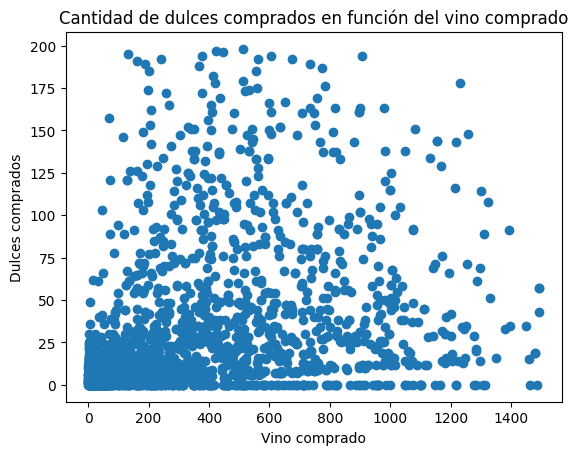

In [25]:
plt.scatter(dataset['MntWines'], dataset['MntSweetProducts'])
plt.title("Cantidad de dulces comprados en función del vino comprado")
plt.xlabel('Vino comprado')
plt.ylabel('Dulces comprados')

Una vez finalizado el análisis, procedemos a eliminar las columnas con elementos tipo string

In [26]:
dataset.drop(columns=['Education', 'Marital_Status'], inplace=True)

In [27]:
#Así queda finalmente el dataset filtrado y modificado
dataset.head()

,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,...,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Edades,N_hijos,Educacion,Estado_Civil
0,58138.0,58,635,88,546,172,88,88,3,8,...,0,0,0,3,11,1,67,0,2,2
1,46344.0,38,11,1,6,2,1,6,2,1,...,0,0,0,3,11,0,70,2,2,2
2,71613.0,26,426,49,127,111,21,42,1,8,...,0,0,0,3,11,0,59,0,2,3
3,26646.0,26,11,4,20,10,3,5,2,2,...,0,0,0,3,11,0,40,1,2,3
4,58293.0,94,173,43,118,46,27,15,5,5,...,0,0,0,3,11,0,43,1,4,1


#**Creación del primer modelo (*K Means*)**

Importamos los módulos y creamos el modelo

In [28]:
from sklearn.cluster import KMeans

## Preparación para la segmentación

Antes de aplicar K-Means hay que resolver tres cosas que afectan el resultado:

1. **Variables constantes.** `Z_CostContact` y `Z_Revenue` valen siempre 3 y 11. No aportan
   información y solo agregan ruido a la distancia.
2. **Escalas incompatibles.** `Income` se mueve en decenas de miles y las variables de conteo
   entre 0 y 10. Como K-Means usa distancia euclidiana, sin escalar el ingreso domina el
   cálculo y la segmentación se reduce a cortar la base por tramos de ingreso.
3. **Alta dimensionalidad.** Con 23 variables las distancias se vuelven poco informativas.
  

También se excluye `Response` de la segmentación: es el resultado que queremos predecir
después, y usarlo acá contaminaría el análisis.

Modificamos el dataset de pandas a numpy para aplicar el modelo

In [29]:
# 1. Eliminamos las variables constantes
dataset.drop(columns=['Z_CostContact', 'Z_Revenue'], inplace=True)

# 2. Escalamos (Response queda fuera: es la variable objetivo de la Parte B)
variables_segmentacion = [c for c in dataset.columns if c != 'Response']
escalador = StandardScaler()
X_escalado = escalador.fit_transform(dataset[variables_segmentacion])

print(f"{len(variables_segmentacion)} variables escaladas")
print(f"Media: {X_escalado.mean():.2f} | Desviación estándar: {X_escalado.std():.2f}")

23 variables escaladas
Media: 0.00 | Desviación estándar: 1.00


In [30]:
# 3. Reducción de dimensionalidad
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_escalado)

print(f"Varianza explicada por componente: {pca.explained_variance_ratio_.round(3)}")
print(f"Varianza acumulada: {pca.explained_variance_ratio_.sum():.1%}")

# Qué representa cada componente
cargas = pd.DataFrame(pca.components_.T, index=variables_segmentacion, columns=['PC1', 'PC2'])
print("\nPC1 — variables con mayor peso:")
print(cargas['PC1'].abs().sort_values(ascending=False).head(5).round(2))
print("\nPC2 — variables con mayor peso:")
print(cargas['PC2'].abs().sort_values(ascending=False).head(5).round(2))

Varianza explicada por componente: [0.293 0.084]
Varianza acumulada: 37.7%

PC1 — variables con mayor peso:
Income                 0.34
NumCatalogPurchases    0.33
MntMeatProducts        0.32
MntWines               0.30
NumStorePurchases      0.28
Name: PC1, dtype: float64

PC2 — variables con mayor peso:
NumDealsPurchases    0.45
NumWebPurchases      0.35
AcceptedCmp4         0.33
N_hijos              0.30
MntWines             0.29
Name: PC2, dtype: float64


PC1 está dominado por `Income`, `NumCatalogPurchases`, `MntMeatProducts` y `MntWines`: es un
eje de **capacidad y volumen de gasto**. PC2 pesa sobre `NumDealsPurchases`, `NumWebPurchases`
y `N_hijos`: es un eje de **sensibilidad al descuento y uso del canal web**.

Dos ejes interpretables: cuánto gasta el cliente, y cómo compra.

##**Optimización del modelo**

Antes de aplicar el modelo de K-Means, analicemos cual es el número de clusters óptimo, para aquello utilizaremos el método del codo y el método de la silueta

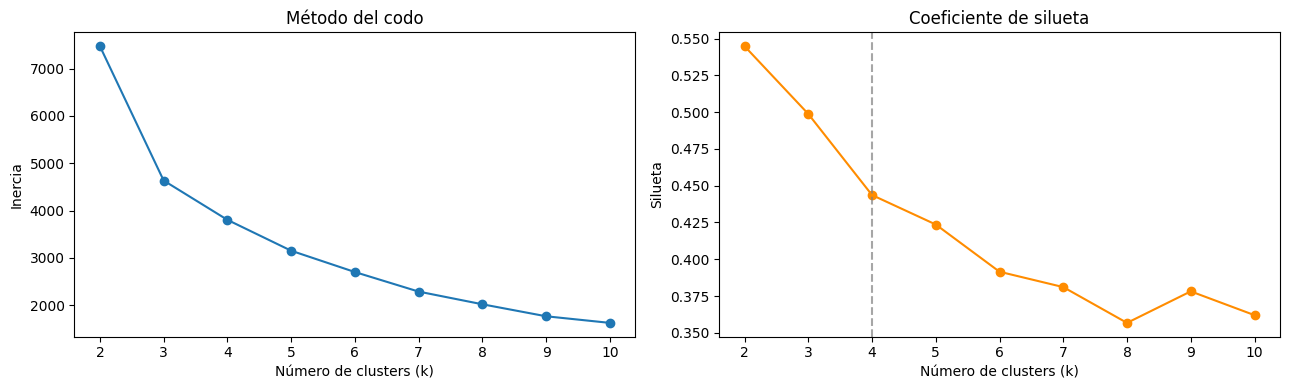

k=2: silueta = 0.545
k=3: silueta = 0.499
k=4: silueta = 0.444
k=5: silueta = 0.424
k=6: silueta = 0.392
k=7: silueta = 0.381
k=8: silueta = 0.357
k=9: silueta = 0.378
k=10: silueta = 0.362


In [31]:
# Elección de k: codo + silueta
inercia, silueta = [], []
rangos_k = range(2, 11)

for k in rangos_k:
    m = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_pca)
    inercia.append(m.inertia_)
    silueta.append(silhouette_score(X_pca, m.labels_))

fig, ejes = plt.subplots(1, 2, figsize=(13, 4))
ejes[0].plot(rangos_k, inercia, marker='o')
ejes[0].set(title='Método del codo', xlabel='Número de clusters (k)', ylabel='Inercia')
ejes[1].plot(rangos_k, silueta, marker='o', color='darkorange')
ejes[1].set(title='Coeficiente de silueta', xlabel='Número de clusters (k)', ylabel='Silueta')
ejes[1].axvline(4, linestyle='--', color='gray', alpha=0.7)
plt.tight_layout()
plt.show()

for k, s in zip(rangos_k, silueta):
    print(f"k={k}: silueta = {s:.3f}")


La silueta máxima está en k = 2 (0.545), pero dos grupos sería una interpretación básica, como "gastan mucho" y "gastan poco".

Por otro lado, **k = 4 conserva una silueta alta (0.444) y
produce cuatro segmentos accionables**, con tamaños balanceados. Se elegirá k=4

In [32]:
K = 4
modelo_kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
dataset['cluster'] = modelo_kmeans.fit_predict(X_pca)

print(f"Silueta con k={K}: {silhouette_score(X_pca, dataset['cluster']):.3f}")
print(dataset['cluster'].value_counts().sort_index())


Silueta con k=4: 0.444
cluster
0    983
1    415
2    421
3    372
Name: count, dtype: int64


##**Análisis de los resultados del modelo**


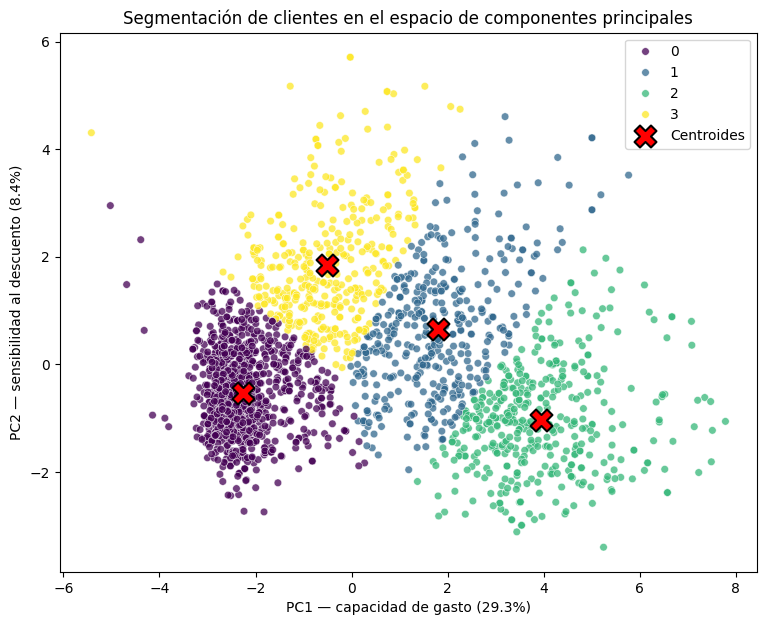

In [33]:
# Visualización de los segmentos en el espacio de componentes principales
plt.figure(figsize=(9, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=dataset['cluster'],
                palette='viridis', s=30, alpha=0.75)
plt.scatter(modelo_kmeans.cluster_centers_[:, 0], modelo_kmeans.cluster_centers_[:, 1],
            c='red', s=250, marker='X', edgecolors='black', linewidths=1.5, label='Centroides')
plt.xlabel(f'PC1 — capacidad de gasto ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 — sensibilidad al descuento ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('Segmentación de clientes en el espacio de componentes principales')
plt.legend()
plt.show()

In [34]:
# Perfil de cada segmento
perfil = dataset.groupby('cluster').agg(
    clientes          = ('Income', 'size'),
    ingreso           = ('Income', 'mean'),
    vino              = ('MntWines', 'mean'),
    carne             = ('MntMeatProducts', 'mean'),
    edad              = ('Edades', 'mean'),
    hijos             = ('N_hijos', 'mean'),
    compras_descuento = ('NumDealsPurchases', 'mean'),
    compras_web       = ('NumWebPurchases', 'mean'),
    compras_catalogo  = ('NumCatalogPurchases', 'mean'),
    compras_tienda    = ('NumStorePurchases', 'mean'),
    visitas_web       = ('NumWebVisitsMonth', 'mean'),
    tasa_respuesta    = ('Response', 'mean')
).round(1)

perfil

,clientes,ingreso,vino,carne,edad,hijos,compras_descuento,compras_web,compras_catalogo,compras_tienda,visitas_web,tasa_respuesta
cluster,,,,,,,,,,,,
0,983,34053.6,37.0,22.2,52.1,1.2,1.9,2.0,0.5,3.2,6.4,0.1
1,415,65837.6,575.4,231.1,58.5,0.8,2.5,6.2,4.4,8.6,4.6,0.2
2,421,77237.3,596.7,499.1,54.6,0.1,1.1,5.0,6.1,8.6,2.5,0.3
3,372,52580.4,387.0,89.5,59.9,1.4,4.5,6.1,2.2,6.5,6.6,0.2


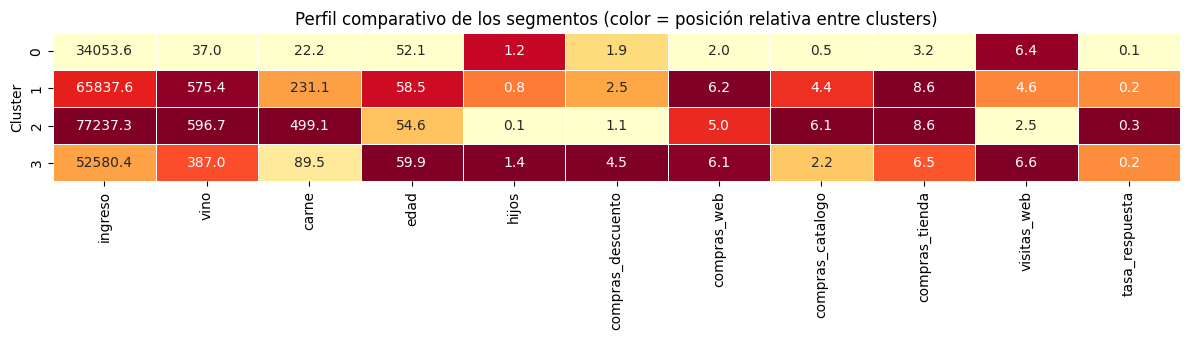

Segmento con mayor consumo de vino: cluster 2


In [35]:
# Mapa de calor comparativo (con cada columna normalizada de 0 a 1)
normalizado = perfil.drop(columns=['clientes']).apply(lambda c: (c - c.min()) / (c.max() - c.min()))

plt.figure(figsize=(12, 3.5))
sns.heatmap(normalizado, annot=perfil.drop(columns=['clientes']).values, fmt='.1f',
            cmap='YlOrRd', cbar=False, linewidths=0.5)
plt.title('Perfil comparativo de los segmentos (color = posición relativa entre clusters)')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

segmento_vino = int(perfil['vino'].idxmax())
print(f"Segmento con mayor consumo de vino: cluster {segmento_vino}")
# → Segmento con mayor consumo de vino: cluster 2

## Interpretación de los segmentos

**Cluster 0: Presupuesto limitado (983 clientes, 45%).** Ingreso de $34.054 y gasto casi
nulo en todas las categorías. Es el grupo que más visita el sitio web (6,4 al mes) y el que
menos compra por cualquier canal. Navegan, no convierten. Enviarles campañas de vino es gasto
publicitario perdido.

**Cluster 1: Aficionados al vino (415 clientes, 19%).** Ingreso de \$65.838 y \$575 en vino,
pero solo \$231 en carne: **es el único segmento donde el vino domina sobre el resto del
gasto**. Son los mayores del grupo (58,5 años) y compran por todos los canales. Para una
campaña específica de vino, este es el público, no el de mayor ingreso.

**Cluster 2: Premium (421 clientes, 19%).** Ingreso de \$77.237 y el gasto más alto en todas
las categorías (\$597 en vino, \$499 en carne). Prácticamente sin hijos (0,1), compran por
catálogo (6,1) y en tienda (8,6), y son los que **menos visitan el sitio web (2,5 al mes)**.
Tienen la mayor tasa de respuesta a campañas (30%). Alto valor y alcanzables solo fuera del
canal digital.

**Cluster 3: Cazadores de ofertas (372 clientes, 17%).** Ingreso medio de $52.580 y, con
diferencia, el mayor uso de compras con descuento (4,5). Muchos hijos (1,4) y alta actividad
web. Responden al precio, no al producto.

### Conclusiones

Los dos segmentos de mayor valor son también los que menos usan el canal digital: el Premium
visita el sitio 2,5 veces al mes frente a las 6,4 del segmento de menor gasto. Una campaña
de vino concentrada en canales digitales estaría llegando justamente a quienes no compran.
Catálogo y tienda física son los canales de este público.

#**Creación del segundo modelo (*KNN*)**

Buscamos responder la pregunta: **Dado un
cliente, ¿aceptará la próxima campaña?**

Predecimos `Response`: si el cliente aceptó la última campaña. Es un resultado
real, observado de forma independiente del resto de las variables, y es exactamente lo que
marketing necesita saber antes de decidir a quién contactar.

Las campañas anteriores (`AcceptedCmp1` a `AcceptedCmp5`) se excluyen: predicen muy bien pero
solo existen para clientes con historial, lo que dejaría el modelo inutilizable con clientes
nuevos.

In [36]:
excluir = ['Response', 'cluster',
           'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']

X = dataset.drop(columns=excluir)
y = dataset['Response']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=11, stratify=y)

print(f"Variables predictoras: {X.shape[1]}")
print(f"Clase positiva: {y.mean():.1%} de la base")


Variables predictoras: 18
Clase positiva: 14.9% de la base


In [37]:
# Comparación de tres algoritmos con validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelos = {
    'KNN': make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=6)),
    'Regresión logística': make_pipeline(StandardScaler(),
                                          LogisticRegression(max_iter=2000, class_weight='balanced')),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=42,
                                            class_weight='balanced')
}

comparacion = {}
for nombre, modelo in modelos.items():
    auc = cross_val_score(modelo, X_train, y_train, cv=cv, scoring='roc_auc')
    f1  = cross_val_score(modelo, X_train, y_train, cv=cv, scoring='f1')
    comparacion[nombre] = {'ROC-AUC': f"{auc.mean():.3f} ± {auc.std():.3f}",
                           'F1':      f"{f1.mean():.3f} ± {f1.std():.3f}"}

pd.DataFrame(comparacion).T

,ROC-AUC,F1
KNN,0.709 ± 0.053,0.117 ± 0.047
Regresión logística,0.811 ± 0.043,0.452 ± 0.060
Random Forest,0.830 ± 0.040,0.292 ± 0.089


El Random Forest ordena mejor a los clientes (ROC-AUC 0,830); la regresión logística tiene
mejor F1 en el umbral por defecto. Como el uso real es **priorizar a quién contactar**, lo
que importa es la capacidad de ordenamiento: se elige  Random Forest.

In [38]:
modelo_final = RandomForestClassifier(n_estimators=300, random_state=42,
                                      class_weight='balanced').fit(X_train, y_train)

probabilidades = modelo_final.predict_proba(X_test)[:, 1]
predicciones   = modelo_final.predict(X_test)

print(f"ROC-AUC: {roc_auc_score(y_test, probabilidades):.3f}")
print(f"PR-AUC:  {average_precision_score(y_test, probabilidades):.3f}")
print()
print(confusion_matrix(y_test, predicciones))
print(classification_report(y_test, predicciones, digits=3))

ROC-AUC: 0.870
PR-AUC:  0.508

[[546  14]
 [ 81  17]]
              precision    recall  f1-score   support

           0      0.871     0.975     0.920       560
           1      0.548     0.173     0.264        98

    accuracy                          0.856       658
   macro avg      0.710     0.574     0.592       658
weighted avg      0.823     0.856     0.822       658



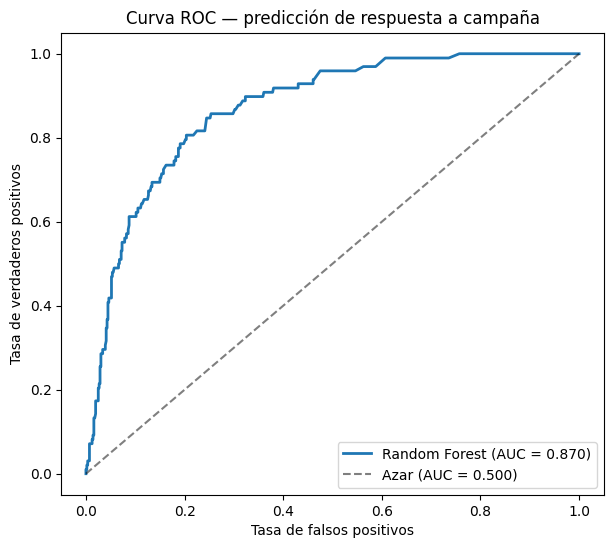

In [39]:
fpr, tpr, _ = roc_curve(y_test, probabilidades)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'Random Forest (AUC = {roc_auc_score(y_test, probabilidades):.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Azar (AUC = 0.500)')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC — predicción de respuesta a campaña')
plt.legend()
plt.show()

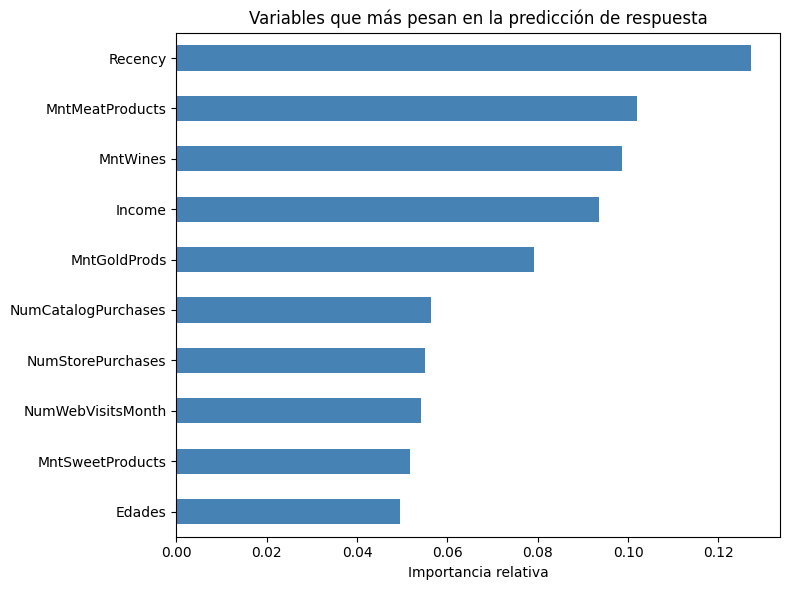

Recency                0.127
MntMeatProducts        0.102
MntWines               0.099
Income                 0.094
MntGoldProds           0.079
NumCatalogPurchases    0.056
dtype: float64


In [40]:
importancias = pd.Series(modelo_final.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(8, 6))
importancias.tail(10).plot(kind='barh', color='steelblue')
plt.xlabel('Importancia relativa')
plt.title('Variables que más pesan en la predicción de respuesta')
plt.tight_layout()
plt.show()

print(importancias.sort_values(ascending=False).head(6).round(3))

In [41]:
# Valor operativo: si solo puedo contactar a una fracción de la base, ¿cuánto gano?
orden = np.argsort(probabilidades)[::-1]
tasa_base = y_test.mean()
filas = []

for porcentaje in [0.05, 0.10, 0.20, 0.30, 0.50]:
    top = orden[:int(len(y_test) * porcentaje)]
    tasa = y_test.iloc[top].mean()
    filas.append({
        '% contactado':       f"{int(porcentaje*100)}%",
        'tasa de aceptación': f"{tasa:.1%}",
        'lift':               f"{tasa/tasa_base:.1f}x",
        'aceptaciones':       int(y_test.iloc[top].sum()),
        '% del total captado':f"{y_test.iloc[top].sum()/y_test.sum():.0%}"
    })

print(f"Tasa de aceptación sin modelo (contactar a todos): {tasa_base:.1%}\n")
pd.DataFrame(filas)

Tasa de aceptación sin modelo (contactar a todos): 14.9%



,% contactado,tasa de aceptación,lift,aceptaciones,% del total captado
0,5%,56.2%,3.8x,18,18%
1,10%,61.5%,4.1x,40,41%
2,20%,48.9%,3.3x,64,65%
3,30%,40.1%,2.7x,79,81%
4,50%,27.4%,1.8x,90,92%


#**Análisis de resultados y conclusiones**

## Conclusiones

**Sobre la segmentación.** Cuatro segmentos con silueta de 0,444 sobre dos componentes
principales que se interpretan como capacidad de gasto y sensibilidad al descuento. El
hallazgo importante es que los segmentos de mayor valor son los que menos usan el canal
digital: el Premium visita el sitio 2,5 veces al mes contra 6,4 del segmento de menor gasto.
Catálogo y tienda, no digital, son los canales para alcanzarlos.

**Sobre la predicción.** El Random Forest alcanza ROC-AUC de 0,870 en el conjunto de prueba
prediciendo la respuesta a campaña. `Recency` —días desde la última compra— es la variable
más informativa, por encima del ingreso: la actividad reciente predice mejor que el poder
adquisitivo.

**El resultado aplicable para el negocio.** Contactando solo al 10% mejor rankeado por el modelo, la tasa de
aceptación sube de 14,9% a 61,5% (lift de 4,1x), capturando el 41% de todas las aceptaciones
posibles. Con el 30% de la base se captura el 81%. En una campaña con costo por contacto, eso
es directamente margen.

**Limitaciones.** Los dos componentes principales retienen 37,7% de la varianza total: la
segmentación captura la estructura dominante, no toda. El modelo predictivo tiene recall bajo
en el umbral por defecto (0,173), lo que es esperable con una clase minoritaria del 15% y no
afecta el uso real, que es de ranking, no de clasificación binaria. Para un despliegue en
producción habría que calibrar el umbral según el costo por contacto y el margen por
conversión.